Используется устройство: cuda


100%|██████████| 170M/170M [37:30<00:00, 75.8kB/s]


X shape: (50000, 32, 32, 3)
y shape: (50000,)
Классов: 10
Размер изображения: 32x32
Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


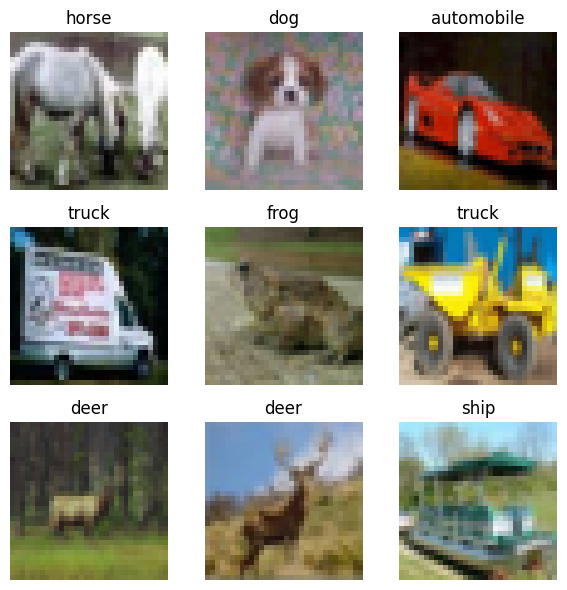

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time, getpass

# Проверяем доступность GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Загружаем CIFAR-10
cifar_train = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
 )

# Формат: (50000, 32, 32, 3), значения пикселей нормализованы в диапазон [0, 1]
X_train = cifar_train.data.astype('float32') / 255.0
y_train = np.array(cifar_train.targets, dtype='int64')

print(f"X shape: {X_train.shape}")
print(f"y shape: {y_train.shape}")
print(f"Классов: {len(np.unique(y_train))}")
print(f"Размер изображения: {X_train.shape[1]}x{X_train.shape[2]}")

cifar_classes = cifar_train.classes
print("Классы:", cifar_classes)

# Смотрим случайные картинки
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(X_train), size=9, replace=False)

plt.figure(figsize=(6, 6))
for plot_index, image_index in enumerate(sample_indices):
    ax = plt.subplot(3, 3, plot_index + 1)
    plt.imshow(X_train[image_index])
    plt.title(cifar_classes[y_train[image_index]])
    plt.axis("off")
plt.tight_layout()
plt.show()

обучить классификатор на cifar-10
провести robustness тестирование с последующим улучшением (стабилизацией) модели

In [ ]:
from sklearn.model_selection import train_test_split

# Берём 10% данных для быстрых экспериментов с гиперпараметрами, сохраняя баланс классов (stratify)
X_train, _, y_train, _ = train_test_split(
    X_train, y_train,
    train_size=0.10,
    random_state=42,
    stratify=y_train
)

print(f"Уменьшенная выборка: X={X_train.shape}, y={y_train.shape}")

Уменьшенная выборка: X=(5000, 32, 32, 3), y=(5000,)


In [ ]:
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [2]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class CIFAR10ArrayDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = Image.fromarray((self.images[index] * 255).astype('uint8'))
        label = int(self.labels[index])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

# Статистики CIFAR-10 для нормализации каналов RGB
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)

# Аугментация применяется только к обучающим изображениям
class AddGaussianNoise:
    def __init__(self, std_range=(0.0, 0.1)):
        self.std_range = std_range

    def __call__(self, tensor):
        std = np.random.uniform(*self.std_range)
        noise = torch.randn_like(tensor) * std
        return torch.clamp(tensor + noise, 0, 1)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
        p=0.3
    ),
    transforms.ToTensor(),
    AddGaussianNoise(std_range=(0.0, 0.1)),
    transforms.Normalize(cifar_mean, cifar_std)
])

# Validation должна быть стабильной и без случайных преобразований
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
 ])

train_dataset = CIFAR10ArrayDataset(
    X_train_part, y_train_part, transform=train_transform
 )
val_dataset = CIFAR10ArrayDataset(
    X_val, y_val, transform=val_transform
 )

train_loader = DataLoader(
    train_dataset, batch_size=512, shuffle=True,
    num_workers=2, pin_memory=True
 )
val_loader = DataLoader(
    val_dataset, batch_size=512, shuffle=False,
    num_workers=2, pin_memory=True
 )

train_images, train_labels = next(iter(train_loader))
print('Train batch:', train_images.shape, train_labels.shape)
print('Validation batch:', next(iter(val_loader))[0].shape)

NameError: name 'X_train_part' is not defined

In [51]:
import torch
import torch.nn as nn

class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.drop_conv1 = nn.Dropout2d(p=0.05)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.drop_conv2 = nn.Dropout2d(p=0.1)

        # CIFAR-10: 32x32 -> 16x16 -> 8x8 after pooling
        self.flatten = nn.Flatten()
        # Corrected: 128 channels * 8x8 feature map size
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 64)
        self.dropout = nn.Dropout(p=0.2)
        self.fc3 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Свертка -> нормализация -> активация -> pooling
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.drop_conv1(x)

        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.drop_conv2(x)

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        # Corrected: Use fc3 for final output after applying ReLU to fc2 output
        x = self.relu(self.fc2(x))
        return self.fc3(x)

model = CIFAR10_CNN(num_classes=10).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

CIFAR10_CNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_conv1): Dropout2d(p=0.05, inplace=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_conv2): Dropout2d(p=0.1, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=64, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 4,304,330


In [52]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """прогоняет по всем данным одной эпохи обучения, обновляет веса модели и возвращает среднюю потерю и точность на обучающей выборке."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader: # итерируемся по обучающей выборке
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True) # перемещаем данные на устройство(гпу)

        optimizer.zero_grad() # очищаем градиенты(что бы не складывал старые с новыми)
        outputs = model(images) # прямой проход (forward pass)
        loss = criterion(outputs, labels) # функция потерь (кросс-энтропия) сравниваем предсказания модели с истинными метками
        loss.backward() # обратный проход (backward pass) - вычисляем градиенты
        optimizer.step() # обновляем веса модели

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1) # получаем индексы максимальных значений (предсказанные классы), отбрасываем первое значение (само значение) через _,
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def validate_epoch(model, dataloader, criterion, device):
    """прогоняет по всем данным валидации одной эпохи, возвращает среднюю потерю и точность на валидационной выборке."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad(): # отключаем градиенты, так как на валидации мы не обучаем модель
        for images, labels in dataloader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [1]:
from torcheval.metrics.functional import multiclass_f1_score
from sklearn.metrics import f1_score

# Loss и optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler (аналог ReduceLROnPlateau) уменьшает learning rate, если метрика не улучшается
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

num_epochs = 80
train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    # Scheduler step для ReduceLROnPlateau, передаем метрику, по которой будем уменьшать learning rate
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        all_predictions.append(outputs.argmax(dim=1).cpu())
        all_targets.append(labels.cpu())

predictions = torch.cat(all_predictions)
targets = torch.cat(all_targets)

macro_f1 = multiclass_f1_score(
    predictions,
    targets,
    num_classes=10,
    average="macro"
)

best_val_acc = max(val_accs)
print(f"\nЛучшая точность на валидации: {best_val_acc * 100:.2f}%")
print(f"Macro-F1 Score: {macro_f1.item():.4f}")

ModuleNotFoundError: No module named 'torcheval'

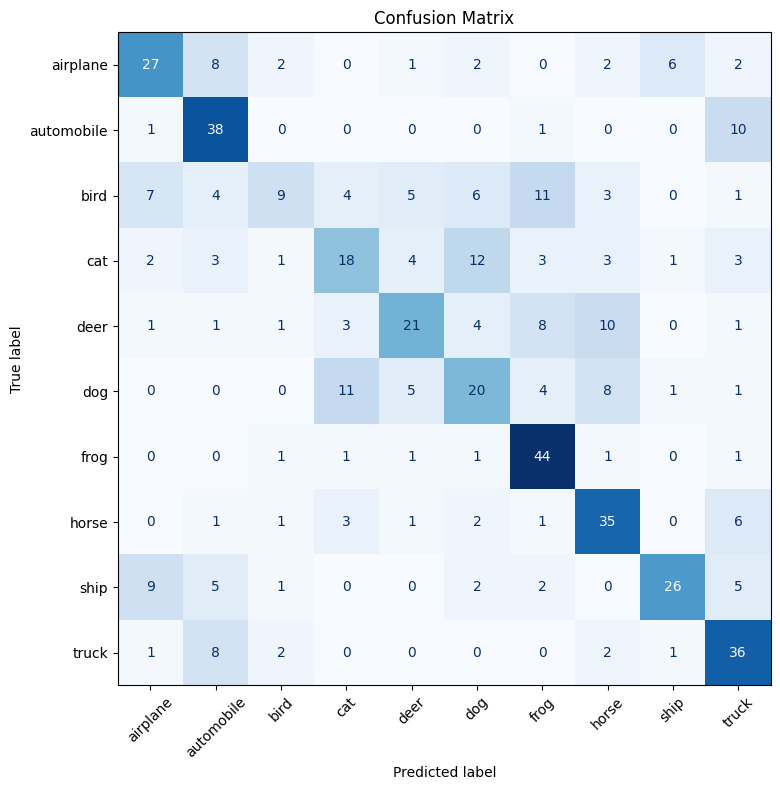

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets.numpy(), predictions.numpy())

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cifar_classes)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [55]:
import numpy as np
from PIL import ImageFilter
import matplotlib.pyplot as plt

def add_gaussian_noise(image, severity):
    arr = np.array(image).astype('float32') / 255.0
    noise = np.random.randn(*arr.shape) * severity
    arr = np.clip(arr + noise, 0, 1)
    return Image.fromarray((arr * 255).astype('uint8'))

def adjust_brightness(image, severity):
    arr = np.array(image).astype('float32') / 255.0
    arr = np.clip(arr + severity, 0, 1)
    return Image.fromarray((arr * 255).astype('uint8'))

def gaussian_blur(image, severity):
    return image.filter(ImageFilter.GaussianBlur(radius=severity))

def rotate_image(image, severity):
    return image.rotate(severity, fillcolor=(0, 0, 0))

class RobustnessDataset(Dataset):
    def __init__(self, images, labels, corruption_fn=None, severity=0, base_transform=val_transform):
        self.images = images
        self.labels = labels
        self.corruption_fn = corruption_fn
        self.severity = severity
        self.base_transform = base_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = Image.fromarray((self.images[index] * 255).astype('uint8'))
        if self.corruption_fn is not None:
            image = self.corruption_fn(image, self.severity)
        image = self.base_transform(image)
        return image, int(self.labels[index])

In [56]:
results_before = results.copy()

In [57]:
corruptions = {
    'gaussian_noise': add_gaussian_noise,
    'brightness': adjust_brightness,
    'blur': gaussian_blur,
    'rotation': rotate_image,
}

severity_levels = {
    'gaussian_noise': [0.0, 0.05, 0.1, 0.2, 0.3],
    'brightness': [0.0, 0.1, 0.2, -0.2, -0.3],
    'blur': [0.0, 0.5, 1.0, 1.5, 2.0],
    'rotation': [0, 5, 10, 20, 30],
}

criterion = nn.CrossEntropyLoss()
results = {}

for name, fn in corruptions.items():
    accs = []
    for sev in severity_levels[name]:
        rob_dataset = RobustnessDataset(X_val, y_val, corruption_fn=fn, severity=sev)
        rob_loader = DataLoader(rob_dataset, batch_size=512, shuffle=False, num_workers=2)
        _, acc = validate_epoch(model, rob_loader, criterion, device)
        accs.append(acc)
    results[name] = accs
    print(f"{name}: {[f'{a:.3f}' for a in accs]}")

gaussian_noise: ['0.548', '0.542', '0.512', '0.442', '0.318']
brightness: ['0.548', '0.544', '0.524', '0.480', '0.438']
blur: ['0.548', '0.546', '0.528', '0.456', '0.386']
rotation: ['0.548', '0.562', '0.548', '0.516', '0.460']


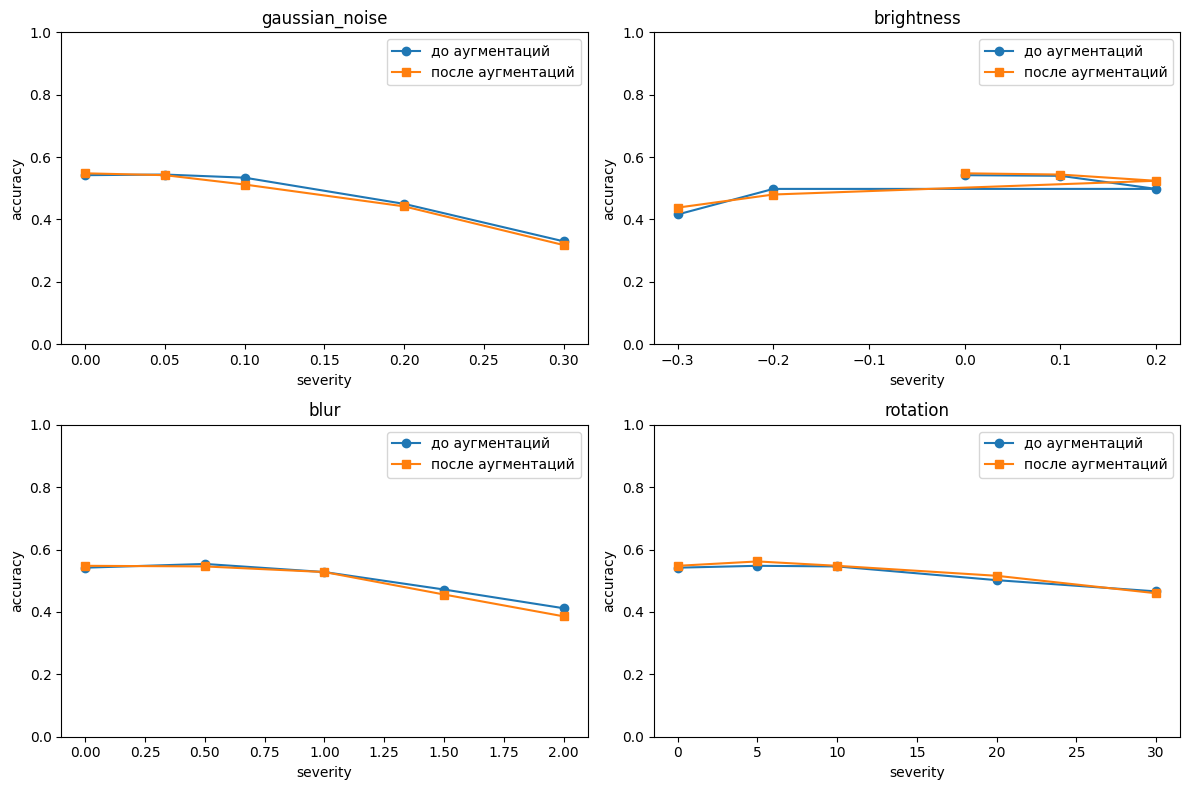

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, name in zip(axes.flat, results.keys()):
    ax.plot(severity_levels[name], results_before[name], marker='o', label='до аугментаций')
    ax.plot(severity_levels[name], results[name], marker='s', label='после аугментаций')
    ax.set_title(name)
    ax.set_xlabel('severity')
    ax.set_ylabel('accuracy')
    ax.set_ylim(0, 1)
    ax.legend()
plt.tight_layout()
plt.show()

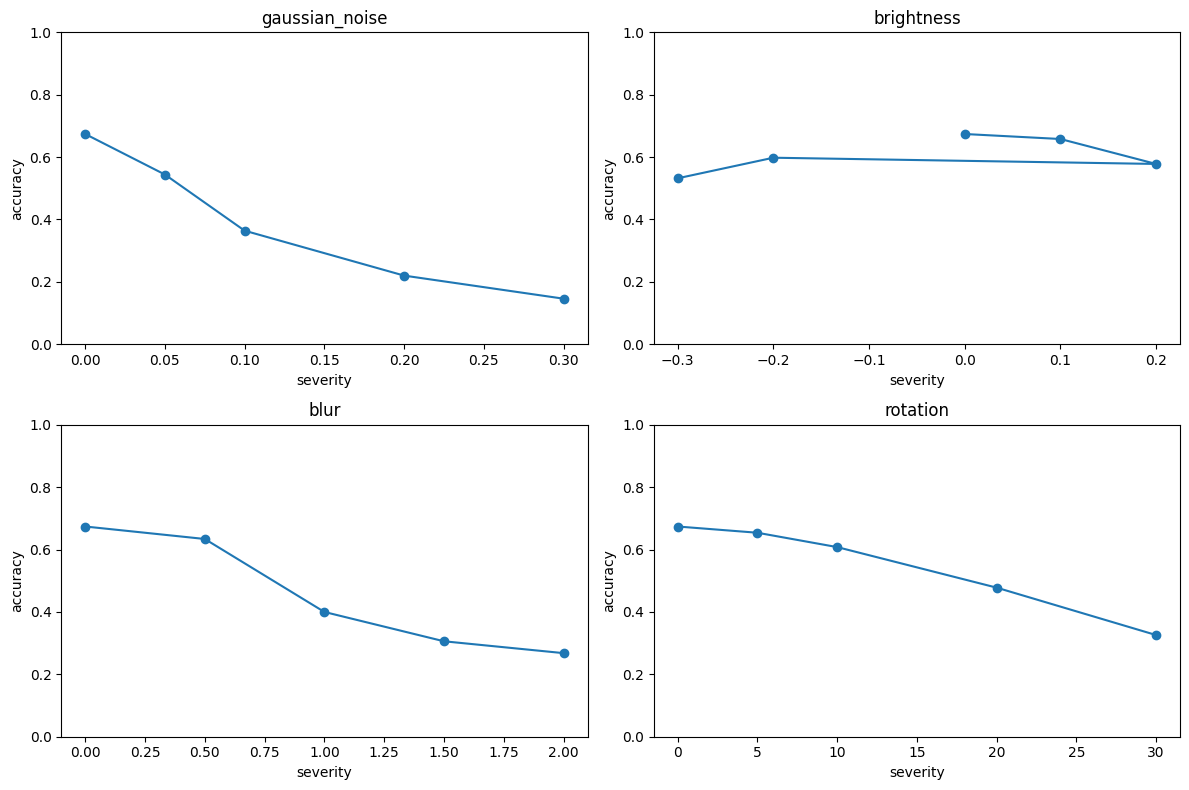

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, accs) in zip(axes.flat, results.items()):
    ax.plot(severity_levels[name], accs, marker='o')
    ax.set_title(name)
    ax.set_xlabel('severity')
    ax.set_ylabel('accuracy')
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [34]:
import torch.nn.functional as F

def grad_cam(model, image_tensor, target_layer, class_idx=None):
    activations, gradients = {}, {}

    def fwd_hook(module, input, output):
        activations['value'] = output

    def bwd_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    model.eval()
    output = model(image_tensor)
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, class_idx].backward()
    h1.remove()
    h2.remove()

    grads = gradients['value'][0]
    acts = activations['value'][0]
    weights = grads.mean(dim=(1, 2))

    cam = torch.zeros(acts.shape[1:], device=acts.device)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = F.relu(cam)
    cam = cam / (cam.max() + 1e-8)
    return cam.detach().cpu().numpy(), class_idx

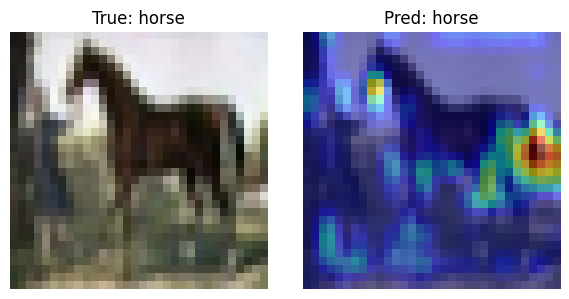

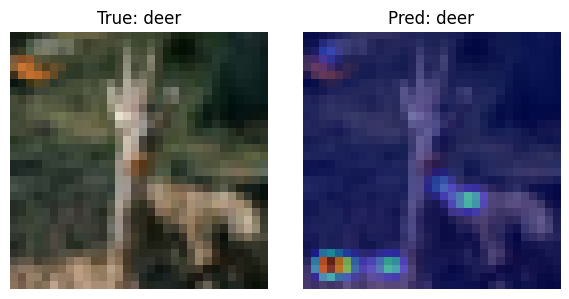

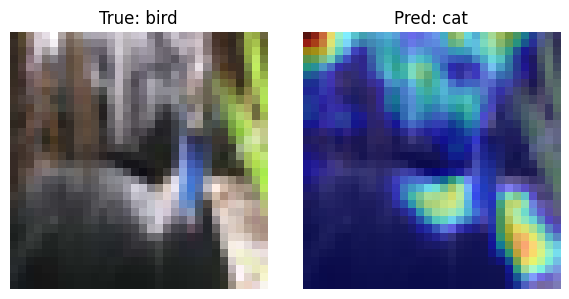

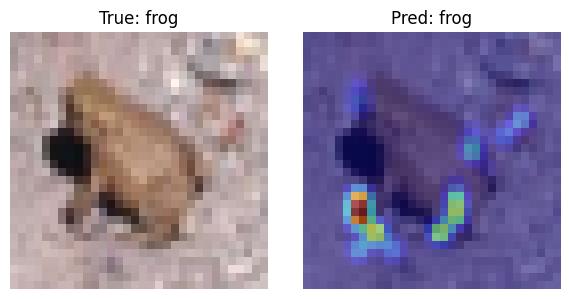

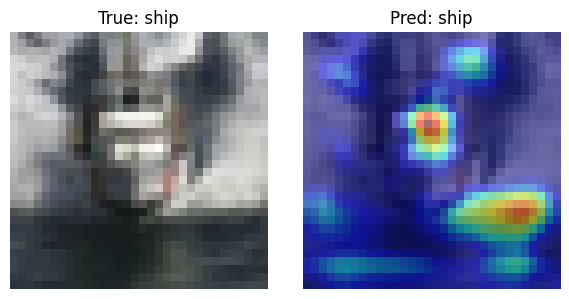

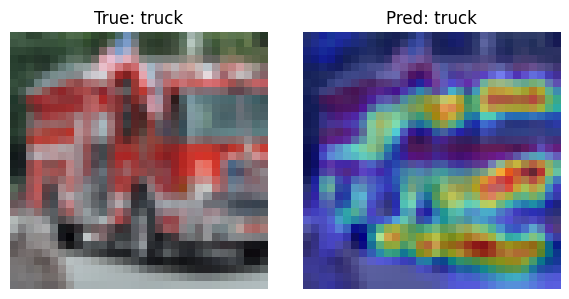

In [35]:
def show_gradcam(model, X, y, index, target_layer, class_names):
    image = X[index]
    input_tensor = val_transform(Image.fromarray((image * 255).astype('uint8'))).unsqueeze(0).to(device)

    cam, pred_class = grad_cam(model, input_tensor, target_layer)
    cam_resized = np.array(Image.fromarray((cam * 255).astype('uint8')).resize((32, 32), Image.BILINEAR)) / 255.0

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(image)
    axes[0].set_title(f"True: {class_names[y[index]]}")
    axes[0].axis('off')

    axes[1].imshow(image)
    axes[1].imshow(cam_resized, cmap='jet', alpha=0.5)
    axes[1].set_title(f"Pred: {class_names[pred_class]}")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

target_layer = model.conv2  # последний сверточный слой перед pooling

rng = np.random.default_rng(0)
sample_idx = rng.choice(len(X_val), size=6, replace=False)
for idx in sample_idx:
    show_gradcam(model, X_val, y_val, idx, target_layer, cifar_classes)

Выводы: weight_decay не улучшает модель, добавление небольшого dropout в сверточный слой улучшает модель
C помощью robustness-тестирования изменены параметры аугментации, также отображена матрица ошибок и grad-cam